In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("03-2024.csv")

In [5]:
df.head()

,Record ID,Activity date,Call direction,Call duration,hs_call_outcome,Activity assigned to
0,48361585291,2024-03-01 08:45,Outbound,00:00:24,NaN,Robin Stoehr
1,48365621428,2024-03-01 08:51,NaN,NaN,NaN,Robin Stoehr
2,48365354301,2024-03-01 08:59,Outbound,00:03:22,NaN,Robin Stoehr
3,48366055533,2024-03-01 09:07,Outbound,00:00:18,NaN,David Valdez
4,48365587300,2024-03-01 09:07,Outbound,00:01:15,NaN,Robin Stoehr


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10997 entries, 0 to 10996
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Record ID             10997 non-null  int64  
 1   Activity date         10997 non-null  str    
 2   Call direction        9560 non-null   str    
 3   Call duration         9814 non-null   str    
 4   hs_call_outcome       0 non-null      float64
 5   Activity assigned to  10808 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 973.9 KB


In [9]:
df1 = df.drop(columns=['hs_call_outcome', 'Record ID'])

In [11]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10997 entries, 0 to 10996
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Activity date         10997 non-null  str  
 1   Call direction        9560 non-null   str  
 2   Call duration         9814 non-null   str  
 3   Activity assigned to  10808 non-null  str  
dtypes: str(4)
memory usage: 802.1 KB


In [13]:
df1['Activity date'] = pd.to_datetime(
    df1['Activity date'],
    format = "%Y-%m-%d %H:%M",
    errors="coerce"
)

In [15]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 10997 entries, 0 to 10996
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10997 non-null  datetime64[us]
 1   Call direction        9560 non-null   str           
 2   Call duration         9814 non-null   str           
 3   Activity assigned to  10808 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 630.3 KB


# Call Count per day

In [18]:
df2 = df1.copy()

In [20]:
df2['date'] = df2['Activity date'].dt.date

In [22]:
df2.head()

,Activity date,Call direction,Call duration,Activity assigned to,date
0,2024-03-01 08:45:00,Outbound,00:00:24,Robin Stoehr,2024-03-01
1,2024-03-01 08:51:00,NaN,NaN,Robin Stoehr,2024-03-01
2,2024-03-01 08:59:00,Outbound,00:03:22,Robin Stoehr,2024-03-01
3,2024-03-01 09:07:00,Outbound,00:00:18,David Valdez,2024-03-01
4,2024-03-01 09:07:00,Outbound,00:01:15,Robin Stoehr,2024-03-01


In [24]:
daily_calls = (
    df2.groupby(df2['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

In [26]:
daily_calls.head()

,date,call_count
0,2024-03-01,514
1,2024-03-02,73
2,2024-03-03,9
3,2024-03-04,506
4,2024-03-05,582


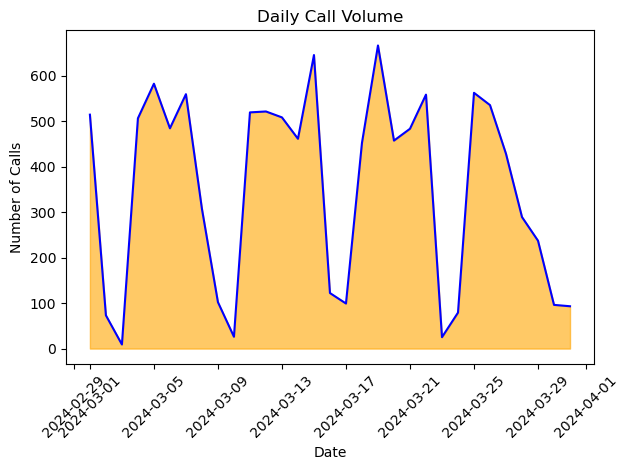

In [30]:
plt.figure()
plt.plot(daily_calls['date'], daily_calls['call_count'], color='blue')

plt.fill_between(daily_calls['date'], daily_calls['call_count'], color = 'orange', alpha=0.6)

plt.title("Daily Call Volume")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Count of Call in Weekdays

In [33]:
df1['day'] = df1['Activity date'].dt.day_name()

In [35]:
df1.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
0,2024-03-01 08:45:00,Outbound,00:00:24,Robin Stoehr,Friday
1,2024-03-01 08:51:00,NaN,NaN,Robin Stoehr,Friday
2,2024-03-01 08:59:00,Outbound,00:03:22,Robin Stoehr,Friday
3,2024-03-01 09:07:00,Outbound,00:00:18,David Valdez,Friday
4,2024-03-01 09:07:00,Outbound,00:01:15,Robin Stoehr,Friday


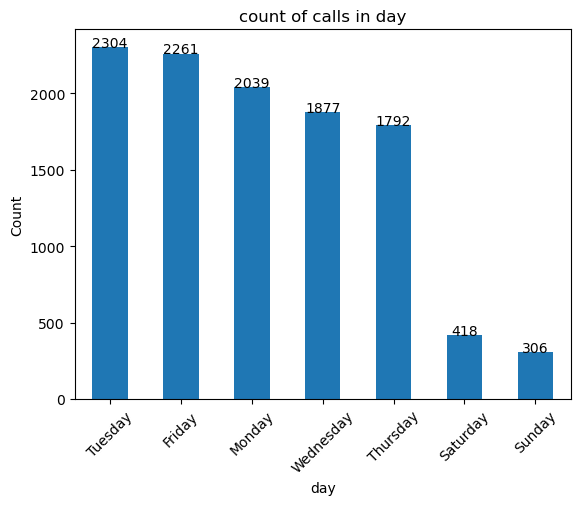

In [37]:
day_Counts = df1["day"].value_counts()
day_Counts.plot(kind='bar')
ax= day_Counts.plot(kind='bar')

for i,v in enumerate(day_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("count of calls in day")
plt.xlabel("day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Inbound VS Outbound

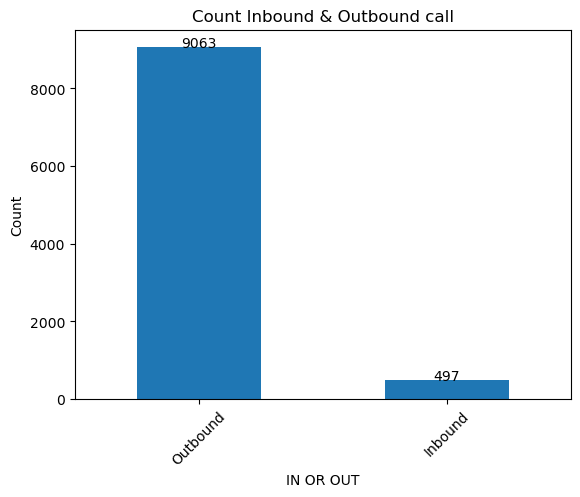

In [40]:
IN_OUT_COUNT = df1['Call direction'].value_counts()
IN_OUT_COUNT.plot(kind='bar')
ax = IN_OUT_COUNT.plot(kind='bar')

for i,v in enumerate(IN_OUT_COUNT):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count Inbound & Outbound call")
plt.xlabel("IN OR OUT")
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# Count 00 Duration for Bound

In [43]:
N_B = df1[(df1['Call duration'] == "00:00:00")]

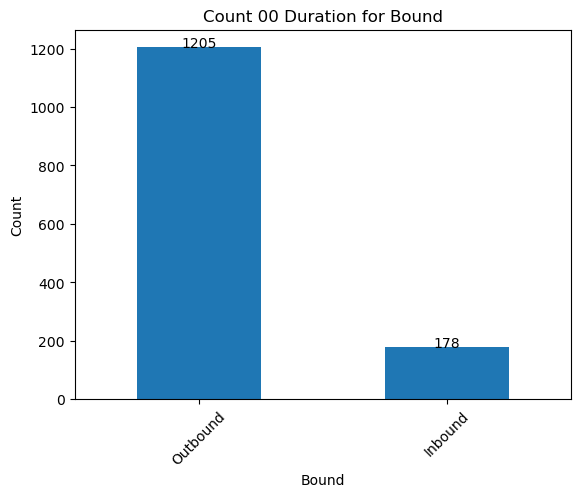

In [45]:
N_B_Counts = N_B['Call direction'].value_counts()
N_B_Counts.plot(kind="bar")
ax = N_B_Counts.plot(kind="bar")

for i,v in enumerate(N_B_Counts):
    ax.text(i, v+1, str(v), ha="center")

plt.title("Count 00 Duration for Bound")
plt.xlabel("Bound")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Call duration NULL but have Call direction

In [48]:
df1[(df1['Call duration'].isnull()) & (df1['Call direction'].notnull())]

,Activity date,Call direction,Call duration,Activity assigned to,day
16,2024-03-01 09:53:00,Inbound,NaN,David Valdez,Friday
232,2024-03-01 15:35:00,Outbound,NaN,Juan Calo,Friday
282,2024-03-01 16:47:00,Inbound,NaN,Robin Stoehr,Friday
598,2024-03-04 10:01:00,Inbound,NaN,Cameron Dudley,Monday
740,2024-03-04 14:39:00,Inbound,NaN,Cameron Dudley,Monday
...,...,...,...,...,...
10334,2024-03-28 11:20:00,Outbound,NaN,Cameron Dudley,Thursday
10337,2024-03-28 11:24:00,Outbound,NaN,Cameron Dudley,Thursday
10473,2024-03-28 16:01:00,Outbound,NaN,Keith Antonio,Thursday
10478,2024-03-28 16:03:00,Outbound,NaN,Jinky Rance,Thursday


In [50]:
df4 = df1.copy()

In [52]:
df4['Call duration'] = (
    pd.to_timedelta(df4['Call duration'], errors = 'coerce')
    .dt.total_seconds()/60
)

In [54]:
(df4['Call duration'] == 0).sum()

1383

In [56]:
df4.info()

<class 'pandas.DataFrame'>
RangeIndex: 10997 entries, 0 to 10996
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         10997 non-null  datetime64[us]
 1   Call direction        9560 non-null   str           
 2   Call duration         9814 non-null   float64       
 3   Activity assigned to  10808 non-null  str           
 4   day                   10997 non-null  str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 714.7 KB


In [58]:
df4['Call duration'] = df4['Call duration'].fillna(0)

In [60]:
df4 = df4.dropna(subset = ['Call direction'])

In [62]:
(df4['Call duration'] == 0).sum()

1491

In [64]:
df4.info()

<class 'pandas.DataFrame'>
Index: 9560 entries, 0 to 10996
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Activity date         9560 non-null   datetime64[us]
 1   Call direction        9560 non-null   str           
 2   Call duration         9560 non-null   float64       
 3   Activity assigned to  9382 non-null   str           
 4   day                   9560 non-null   str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 701.9 KB


# Working Call Assigner 

In [67]:
df1['Activity assigned to'].nunique()

22

In [69]:
df1['Activity assigned to'].unique()

<ArrowStringArray>
[          'Robin Stoehr',           'David Valdez',       'Vladimir Suparto',
              'Juan Calo',           'Louis Maciel',         'Cameron Dudley',
          'Sam Steindorf',          'Garrett Evans',          'Oliver Martin',
            'Paol Guzman',                      nan,    'Demmie Rose Tamonan',
      'Brittany Digiulio',           'Karen Parker',            'Jinky Rance',
         'David Banister',       'Chrystel Manabat',          'Keith Antonio',
 'Jannica Nikka Antipuna',        'Adonis Baybayan',             'Henry Good',
           'Bill Goodwin',          'Tanner Schunk']
Length: 23, dtype: str

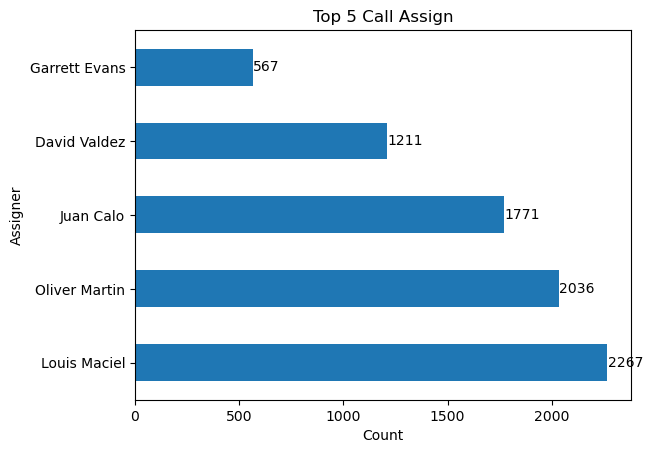

In [71]:
ASSI_COUNT = df1['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Max Call Duration

In [74]:
df4['Call duration'].max()

163.6

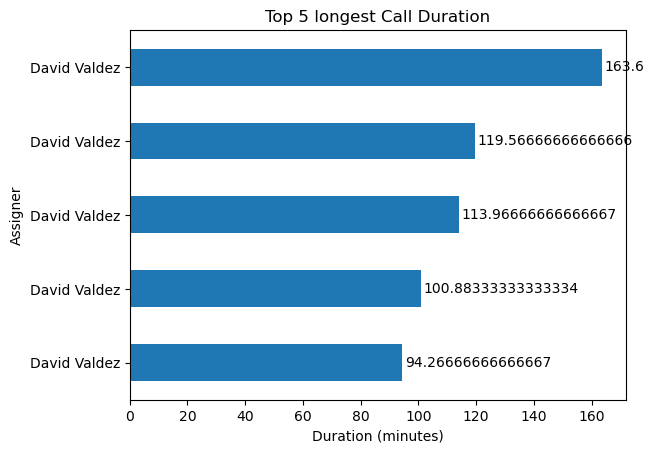

In [76]:
top5 = df4.nlargest(5, "Call duration")

ax = top5.set_index('Activity assigned to')['Call duration'].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Only Weekdays Call Volume

In [79]:
df3 = df1.copy()

In [81]:
df3 = df3[~df3['day'].isin(['Saturday', 'Sunday'])]

In [83]:
df3['day'].unique()

<ArrowStringArray>
['Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Length: 5, dtype: str

In [85]:
week_day_calls=(
    df3.groupby(df3['Activity date'].dt.date)
    .size()
    .reset_index(name='call_count')
    .rename(columns={'Activity date': 'date'})
)

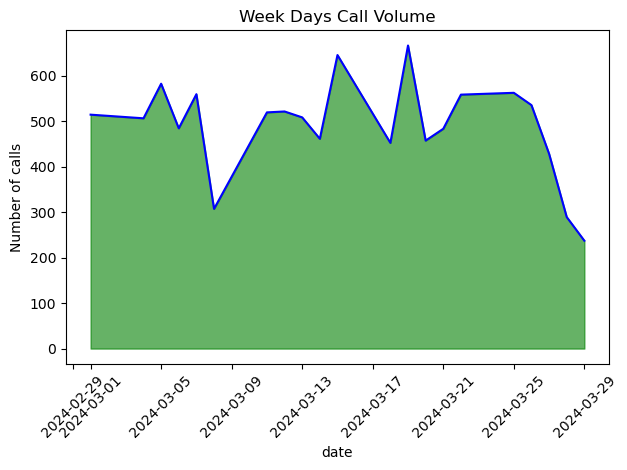

In [87]:
plt.figure()
plt.plot(week_day_calls['date'], week_day_calls['call_count'], color='blue')

plt.fill_between(week_day_calls['date'], week_day_calls['call_count'],color='green', alpha=0.6)

plt.title("Week Days Call Volume")
plt.xlabel("date")
plt.ylabel("Number of calls")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# WEEKEND TIME DURATION

In [90]:
df5=df4.copy()

In [92]:
df5 = df5[~df5['day'].isin(['Monday', 'Thursday', 'Friday', 'Wednesday', 'Tuesday'])]

In [94]:
df5.head()

,Activity date,Call direction,Call duration,Activity assigned to,day
514,2024-03-02 09:14:00,Outbound,0.583333,Vladimir Suparto,Saturday
515,2024-03-02 09:15:00,Outbound,0.533333,Vladimir Suparto,Saturday
516,2024-03-02 10:00:00,Outbound,0.233333,Garrett Evans,Saturday
518,2024-03-02 10:12:00,Inbound,0.000000,NaN,Saturday
519,2024-03-02 10:25:00,Outbound,0.166667,Karen Parker,Saturday


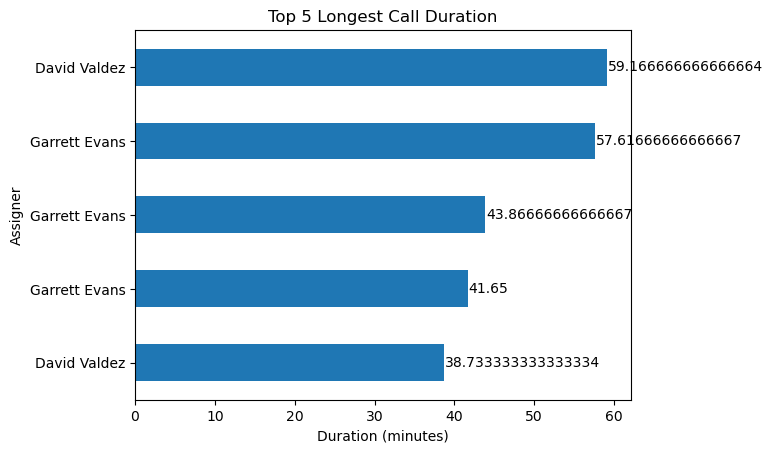

In [96]:
top5 = df5.nlargest(5, "Call duration")

ax = top5.set_index("Activity assigned to")["Call duration"].sort_values().plot(kind="barh")

for i, v in enumerate(top5["Call duration"].sort_values()):
    ax.text(v + 0.1, i, str(v), va="center")

plt.title("Top 5 Longest Call Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Assigner")
plt.show()

# Top 5 Weekend Call Assigner

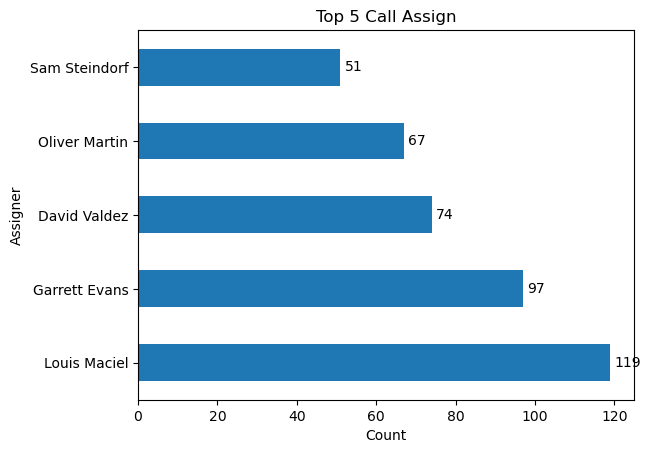

In [99]:
ASSI_COUNT = df5['Activity assigned to'].value_counts().head(5)

ax = ASSI_COUNT.plot(kind='barh')

for i,v in enumerate(ASSI_COUNT):
    ax.text(v+1, i, str(v), va="center")

plt.title("Top 5 Call Assign")
plt.xlabel("Count")
plt.ylabel("Assigner")
plt.show()

# Average Call Duration

In [102]:
df4["Call duration"].mean()

1.480876917712692

In [104]:
df4["Call duration"].median()

0.2

# Without Call Assigner Calls

In [107]:
df6 = df3.copy()

In [109]:
df6['month'] = df6['Activity date'].dt.month_name()

In [111]:
no_assigner_calls = df6[df6["Activity assigned to"].isna()]

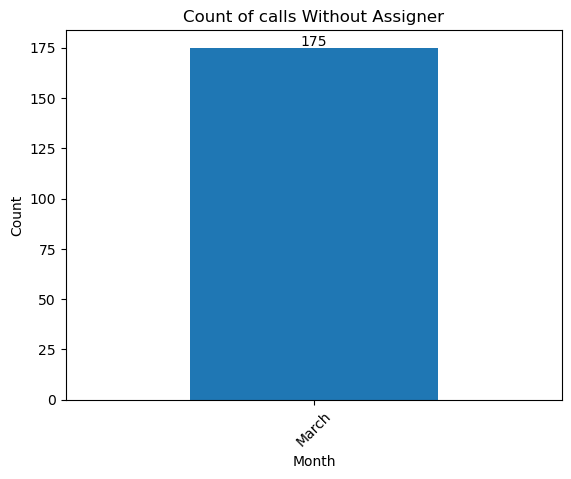

In [113]:
month_counts = no_assigner_calls["month"].value_counts()
month_counts.plot(kind="bar")
ax = month_counts.plot(kind="bar")

for i, v in enumerate(month_counts):
    ax.text(i, v + 1, str(v), ha="center")

plt.title("Count of calls Without Assigner")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# Top 5 Peak Call date

In [116]:
daily_calls = df.groupby(df2["Activity date"].dt.date).size()

In [118]:
top5 = daily_calls.sort_values(ascending=False).head(5)

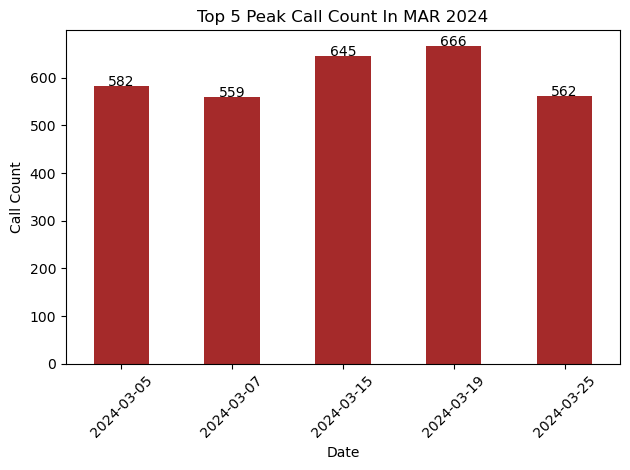

In [122]:
ax = top5.sort_index().plot(kind="bar", color="brown")

for i, v in enumerate(top5.sort_index()):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=10)
    
plt.title("Top 5 Peak Call Count In MAR 2024")
plt.xlabel("Date")
plt.ylabel("Call Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()